Fig 1

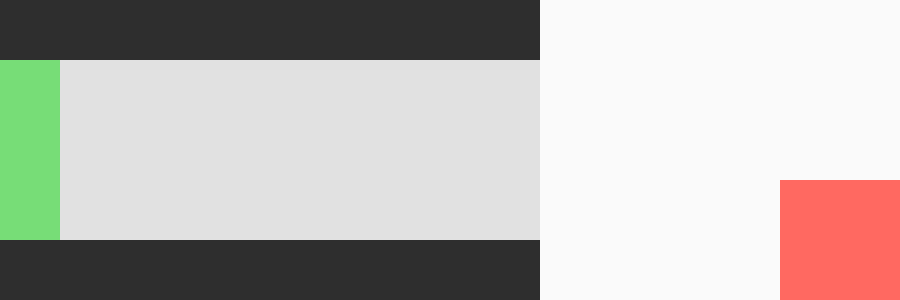

In [6]:
import numpy as np
from PIL import Image, ImageDraw

# 1. Setup the Mask
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

# 2. Settings
cell_size = 60
rows, cols = mask.shape

# Revised Palette
colors = {
    'wall':           (46, 46, 46),    # Dark Grey
    'shelter':        (119, 221, 119), # Pastel Green
    'threat':         (255, 105, 97),  # Pastel Red
    # Split floor colors
    'floor_corridor': (225, 225, 225), # Light Grey
    'floor_chamber':  (250, 250, 250)  # Bright White
}

# 3. Create Image Canvas
img = Image.new('RGB', (cols * cell_size, rows * cell_size), colors['wall'])
draw = ImageDraw.Draw(img)

# 4. Draw the Grid
for r in range(rows):
    for c in range(cols):
        x0, y0 = c * cell_size, r * cell_size
        x1, y1 = x0 + cell_size, y0 + cell_size
        
        # Determine Color Priority: Wall -> Shelter -> Threat -> Floor Zone
        if not mask[r, c]:
            fill = colors['wall']
        elif c == 0 and 1 <= r <= 3:      # Shelter
            fill = colors['shelter']
        elif c >= 13 and r >= 3:          # Threat
            fill = colors['threat']
        else:
            # It's floor, check zone based on column index
            # Columns 0-8 are corridor, 9-14 are chamber
            if c <= 8:
                fill = colors['floor_corridor']
            else:
                fill = colors['floor_chamber']
            
        # Draw borderless rectangle (removed outline argument)
        draw.rectangle([x0, y0, x1, y1], fill=fill)

# 5. Display
img

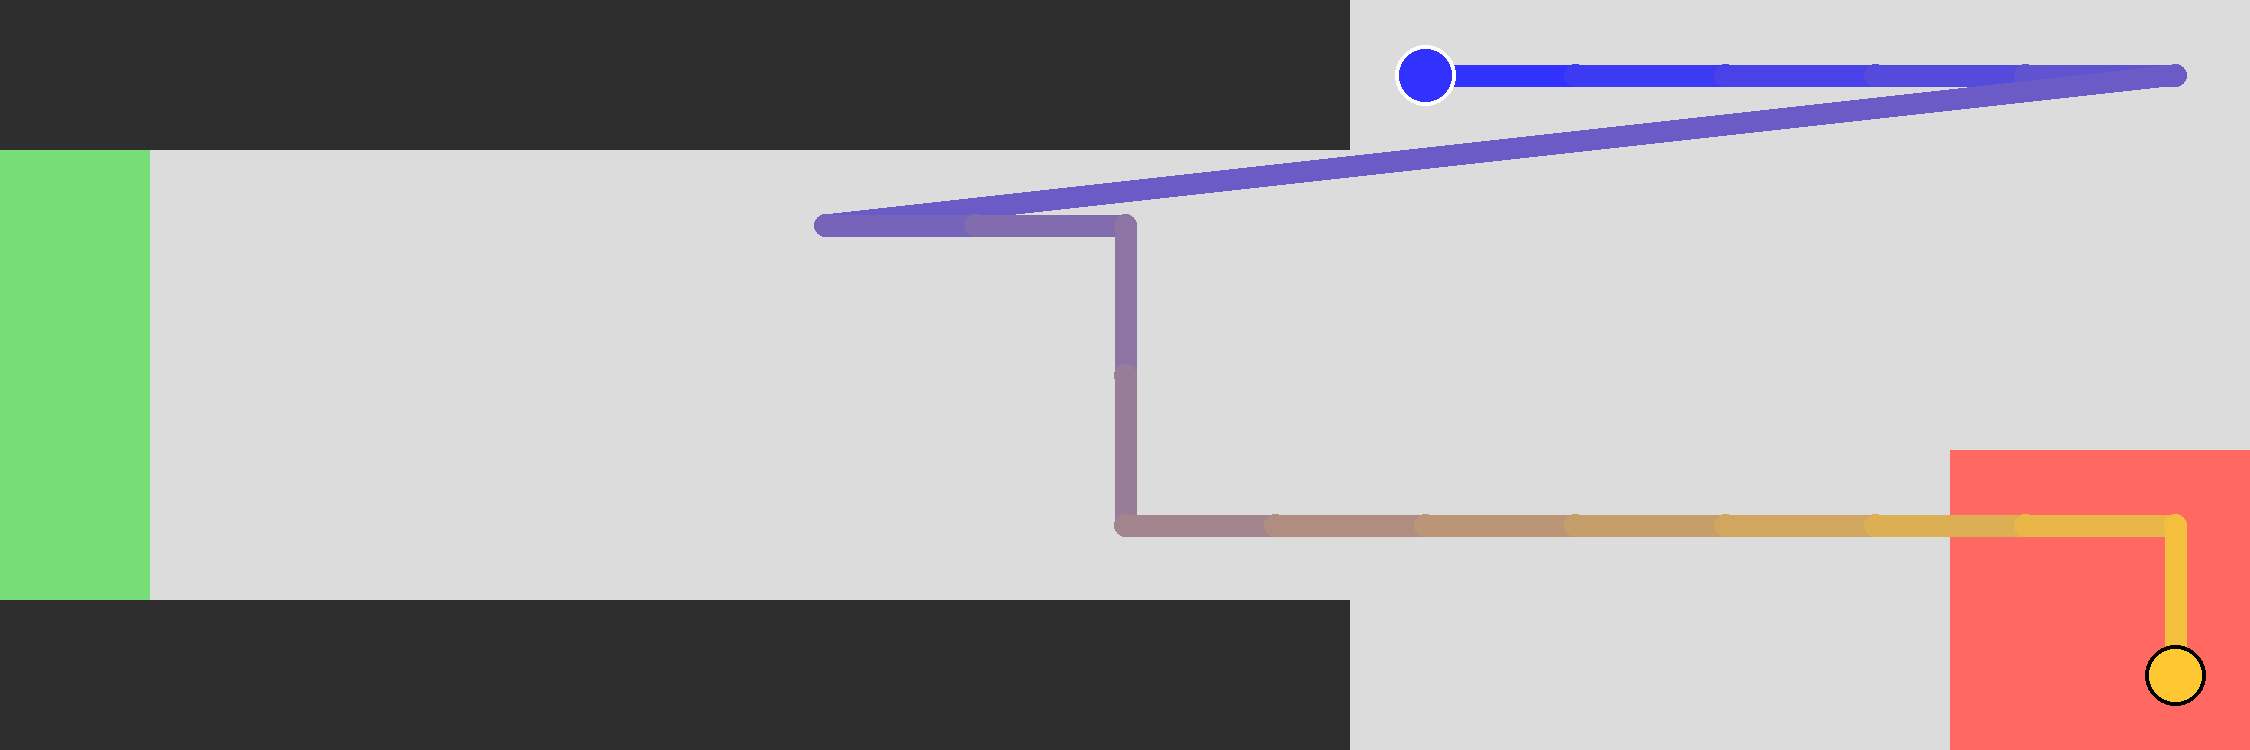

In [8]:
import numpy as np
from PIL import Image, ImageDraw

# 1. Setup Mask
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

# 2. HIGH RES SETTINGS
cell_size = 150  # Increased from 60 to 150 for sharp resolution
rows, cols = mask.shape

# Scale graphical elements based on cell_size
line_width = int(cell_size * 0.15)  # Thick trace line
joint_radius = line_width // 2      # Smooth joints
marker_radius = int(cell_size * 0.2) # Start/End dots

# 3. Colors
colors = {
    'wall':    (46, 46, 46),
    'floor':   (220, 220, 220), # Uniform Grey
    'shelter': (119, 221, 119),
    'threat':  (255, 105, 97),
    'start':   (50, 50, 255),   # Blue
    'end':     (255, 200, 50)   # Yellow
}

# 4. Coordinate Mapping
idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1

# 5. Define Trajectory
example_trajectory = [
    0, 1, 2, 3, 4, 5,              
    11, 12, 13, 28, 43, 44,        
    45, 46, 47, 48, 49, 50, 56     
]

# 6. Helper: Gradient Color
def get_gradient_color(progress, start_rgb, end_rgb):
    r = int(start_rgb[0] + (end_rgb[0] - start_rgb[0]) * progress)
    g = int(start_rgb[1] + (end_rgb[1] - start_rgb[1]) * progress)
    b = int(start_rgb[2] + (end_rgb[2] - start_rgb[2]) * progress)
    return (r, g, b)

# 7. Draw Base Arena
img = Image.new('RGB', (cols * cell_size, rows * cell_size), colors['wall'])
draw = ImageDraw.Draw(img)

for r in range(rows):
    for c in range(cols):
        x0, y0 = c * cell_size, r * cell_size
        x1, y1 = x0 + cell_size, y0 + cell_size
        
        if not mask[r, c]:
            fill = colors['wall']
        elif c == 0 and 1 <= r <= 3:
            fill = colors['shelter']
        elif c >= 13 and r >= 3:
            fill = colors['threat']
        else:
            fill = colors['floor']
            
        draw.rectangle([x0, y0, x1, y1], fill=fill)

# 8. Draw High-Res Trajectory
if len(example_trajectory) > 1:
    points = []
    for idx in example_trajectory:
        r, c = idx_to_rc[idx]
        px = c * cell_size + cell_size // 2
        py = r * cell_size + cell_size // 2
        points.append((px, py))

    num_segments = len(points) - 1
    for i in range(num_segments):
        progress = i / max(1, num_segments)
        color = get_gradient_color(progress, colors['start'], colors['end'])
        
        p1 = points[i]
        p2 = points[i+1]
        
        # Draw Line
        draw.line([p1, p2], fill=color, width=line_width)
        
        # Draw Smooth Joint (Circle)
        # This covers the gaps between jagged line segments
        draw.ellipse([p1[0]-joint_radius, p1[1]-joint_radius, 
                      p1[0]+joint_radius, p1[1]+joint_radius], fill=color)

    # Markers (Start/End)
    start_pt = points[0]
    end_pt = points[-1]
    
    # Start (Blue with White Border)
    draw.ellipse([start_pt[0]-marker_radius, start_pt[1]-marker_radius, 
                  start_pt[0]+marker_radius, start_pt[1]+marker_radius], 
                 fill=colors['start'], outline=(255,255,255), width=int(cell_size*0.03))
    
    # End (Yellow with Black Border)
    draw.ellipse([end_pt[0]-marker_radius, end_pt[1]-marker_radius, 
                  end_pt[0]+marker_radius, end_pt[1]+marker_radius], 
                 fill=colors['end'], outline=(0,0,0), width=int(cell_size*0.03))

# Resize for display in notebook if needed, or keep high-res
# img.resize((cols*60, rows*60), resample=Image.LANCZOS) # Optional: Scale down for preview
img

/tmp/ipykernel_7812/382408452.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('inferno')


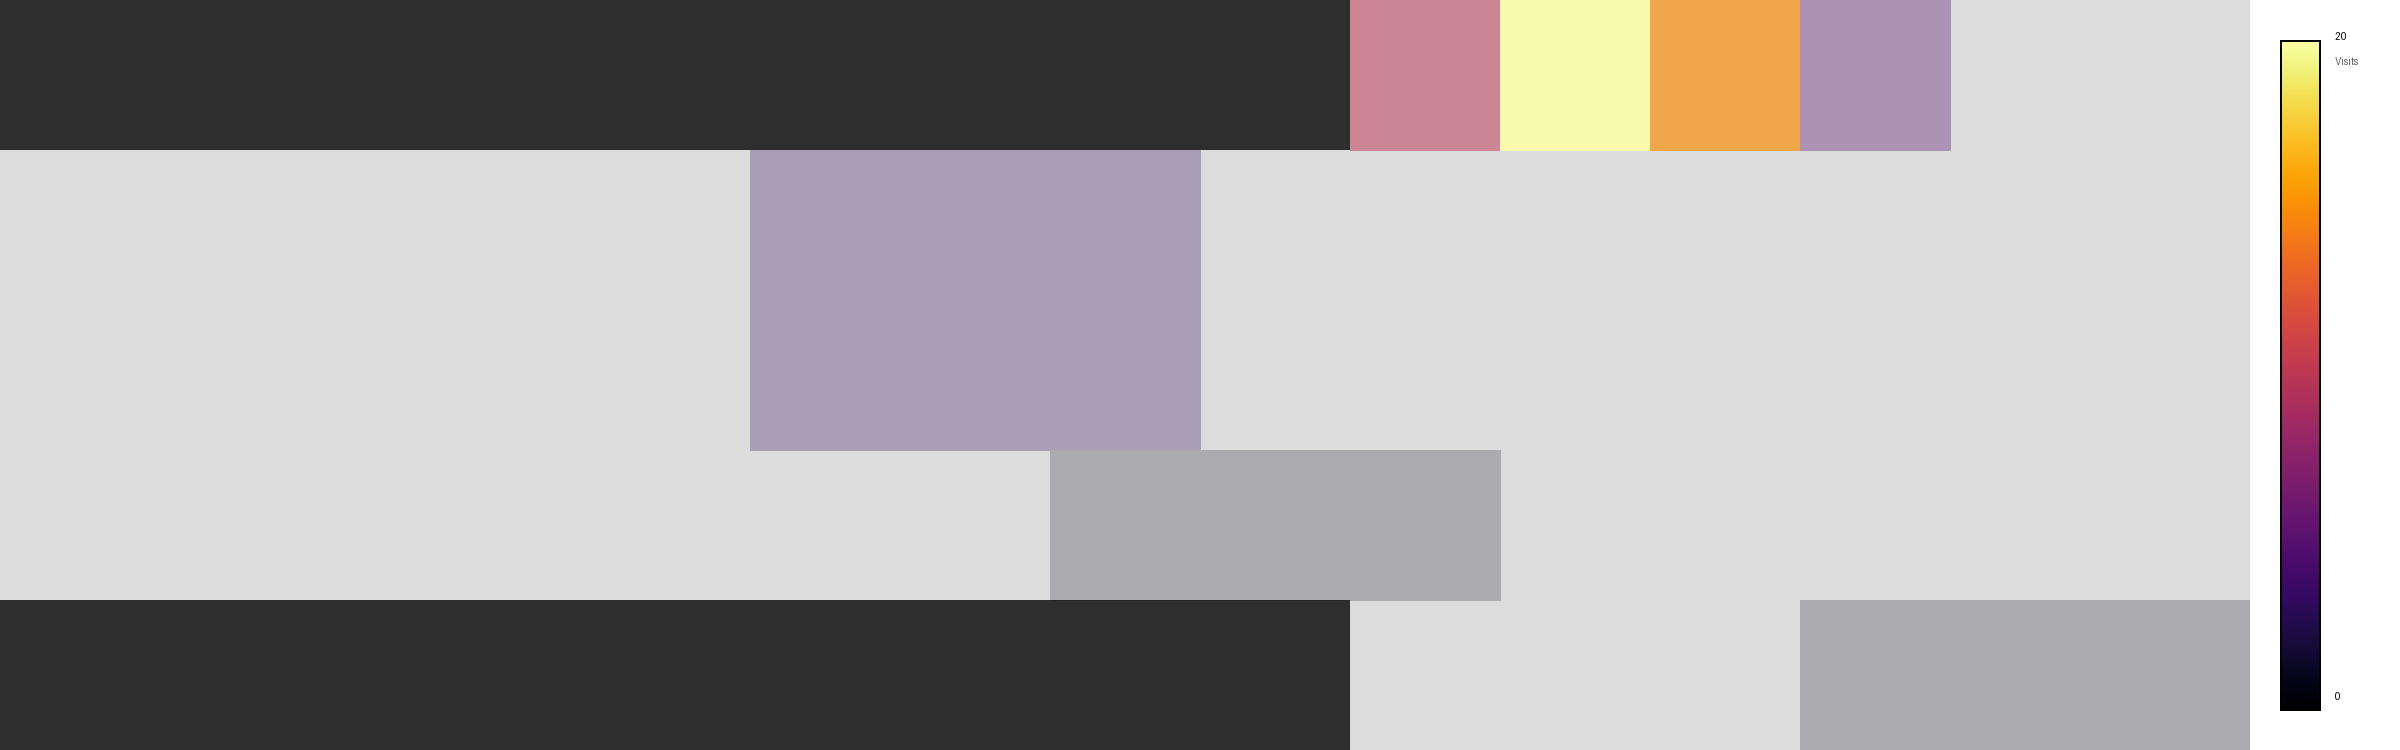

In [12]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from collections import Counter
import matplotlib.cm as cm

# 1. Setup Mask & Constants
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

cell_size = 150
rows, cols = mask.shape

# Colors
c_wall = (46, 46, 46)
c_floor = (220, 220, 220)

# 2. Trajectory & Counts
# Using the same example data
idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1

example_trajectory = (
    [0, 1, 2, 1, 0, 1, 2, 3, 2, 1] * 5 + 
    [11, 12, 13, 28, 27, 26] * 3 +       
    [43, 44, 45, 56, 55, 54] * 1          
)

visit_counts = Counter(example_trajectory)
max_visits = max(visit_counts.values()) if visit_counts else 1

# 3. Draw Grid (Same as before)
base_img = Image.new('RGB', (cols * cell_size, rows * cell_size), c_wall)
base_draw = ImageDraw.Draw(base_img)

for r in range(rows):
    for c in range(cols):
        x0, y0 = c * cell_size, r * cell_size
        x1, y1 = x0 + cell_size, y0 + cell_size
        if not mask[r, c]:
            base_draw.rectangle([x0, y0, x1, y1], fill=c_wall, outline=None)
        else:
            base_draw.rectangle([x0, y0, x1, y1], fill=c_floor, outline=None)

# 4. Heatmap Overlay
overlay_img = Image.new('RGBA', base_img.size, (0,0,0,0))
overlay_draw = ImageDraw.Draw(overlay_img)
colormap = cm.get_cmap('inferno')

for idx, count in visit_counts.items():
    r, c = idx_to_rc[idx]
    x0, y0 = c * cell_size, r * cell_size
    intensity = count / max_visits
    rgba_float = colormap(intensity)
    r_val, g_val, b_val = [int(x*255) for x in rgba_float[:3]]
    alpha_val = int(50 + (intensity * 170))
    
    inset = 0
    overlay_draw.rectangle([x0+inset, y0+inset, x0+cell_size-inset, y0+cell_size-inset], 
                           fill=(r_val, g_val, b_val, alpha_val))

grid_img = Image.alpha_composite(base_img.convert('RGBA'), overlay_img)

# --- 5. CREATE LEGEND BAR ---
legend_width = 150  # Width of the side panel
bar_width = 40      # Width of the colored gradient strip
padding = 40        # Top/Bottom padding for the strip

# Create Legend Canvas
legend_img = Image.new('RGB', (legend_width, grid_img.height), (255, 255, 255))
legend_draw = ImageDraw.Draw(legend_img)

# Draw Gradient Strip
bar_height = grid_img.height - (padding * 2)
bar_x = 30 # X position of the bar
bar_y_start = padding

# We draw the gradient line by line
for y in range(bar_height):
    # Normalized height (0.0 at bottom, 1.0 at top)
    progress = 1.0 - (y / bar_height) # Inverted so Hot/Top is at the top
    
    # Get color from same colormap
    rgba = colormap(progress)
    color = tuple(int(c * 255) for c in rgba[:3])
    
    # Draw 1px horizontal line
    legend_draw.line(
        [(bar_x, bar_y_start + y), (bar_x + bar_width, bar_y_start + y)], 
        fill=color
    )

# Draw Outline around bar
legend_draw.rectangle(
    [bar_x, bar_y_start, bar_x + bar_width, bar_y_start + bar_height], 
    outline=(0,0,0), width=2
)

# Add Text Labels
try:
    # Try to load a nicer font, fallback to default
    font = ImageFont.truetype("arial.ttf", 30)
    font_title = ImageFont.truetype("arial.ttf", 24)
except IOError:
    font = ImageFont.load_default()
    font_title = ImageFont.load_default()

# Label Positions
text_x = bar_x + bar_width + 15

# "Max" Label
legend_draw.text((text_x, bar_y_start - 10), f"{max_visits}", fill=(0,0,0), font=font)
legend_draw.text((text_x, bar_y_start + 15), "Visits", fill=(100,100,100), font=font_title)

# "0" Label
legend_draw.text((text_x, bar_y_start + bar_height - 20), "0", fill=(0,0,0), font=font)

# --- 6. COMBINE GRID + LEGEND ---
final_w = grid_img.width + legend_img.width
final_h = grid_img.height
final_composite = Image.new('RGB', (final_w, final_h))
final_composite.paste(grid_img, (0, 0))
final_composite.paste(legend_img, (grid_img.width, 0))

final_composite